# **Phân Tích Tập Dữ Liệu**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from scipy.stats import entropy
from collections import Counter

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix

from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

## **1. CẤU HÌNH**

In [2]:

DATA_PATH = "https://github.com/ltdaovn/dataset/raw/master/Rice2025.xlsx"

TARGET_COLUMN = "Class"
FEATURE_COLUMNS = [
    "Area",
    "Perimeter",
    "Major_Axis_Length",
    "Minor_Axis_Length",
    "Eccentricity",
    "Convex_Area",
    "Convex_Area_2",
    "Extent"
]

## **2. TẢI & TÌM HIỂU DỮ LIỆU**

Đang tải dữ liệu từ: https://github.com/ltdaovn/dataset/raw/master/Rice2025.xlsx
Tải dữ liệu thành công!

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3822 entries, 0 to 3821
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Id                 3822 non-null   int64  
 1   Nickname           3822 non-null   object 
 2   Class              3822 non-null   object 
 3   Area               3822 non-null   int64  
 4   Perimeter          3820 non-null   object 
 5   Major_Axis_Length  3821 non-null   float64
 6   Minor_Axis_Length  3820 non-null   float64
 7   Eccentricity       3819 non-null   float64
 8   Convex_Area        3820 non-null   float64
 9   Convex_Area_2      3822 non-null   int64  
 10  Extent             3821 non-null   float64
dtypes: float64(5), int64(3), object(3)
memory usage: 328.6+ KB

NHÃN TRƯỚC KHI XỬ LÝ (unique): ['C' 'c' 'O' 'o']
Số lượng từng nhãn (trước khi xử lý):
Class
O    

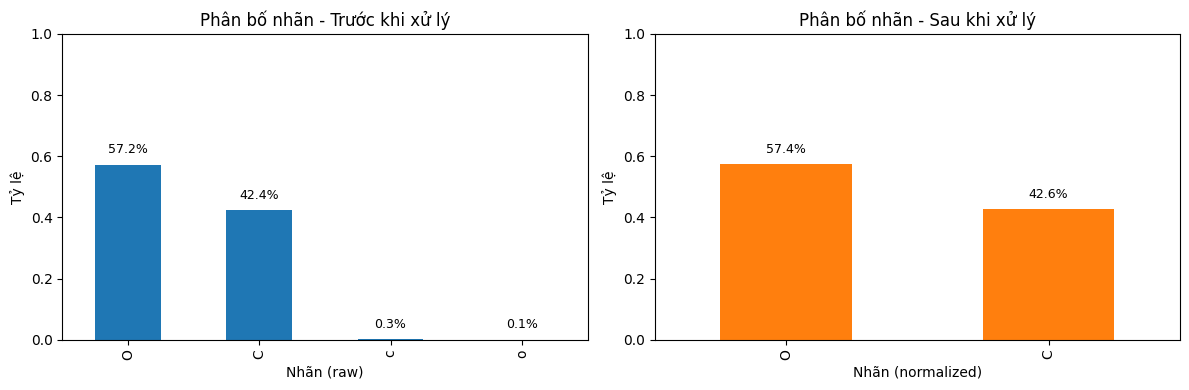

Số lượng mẫu:  3822
Số lượng thuộc tính:  10
Dữ liệu tổng quát:


,Id,Nickname,Class,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Convex_Area_2,Extent
0,1,R1,C,15231,525.578979,229.749878,85.093788,0.928882,15617.0,31234,0.572896
1,2,R2,C,14656,494.311005,206.020065,91.730972,0.895405,15072.0,30144,0.615436
2,3,R3,C,14634,501.122009,214.106781,87.768288,0.912118,14954.0,29908,0.693259
3,4,R4,C,13176,458.342987,193.337387,87.448395,0.891861,13368.0,26736,0.640669
4,5,R5,C,14688,507.166992,211.743378,89.312454,0.906691,15262.0,30524,0.646024
...,...,...,...,...,...,...,...,...,...,...,...
3817,3818,R3818,O,11944,434.924011,182.873962,83.638435,0.889284,12090.0,24180,0.617197
3818,3819,R3819,O,12800,447.024994,181.769089,90.766342,0.866401,12958.0,25916,0.610221
3819,3820,R3820,O,11605,425.697998,173.516678,86.135109,0.868089,11781.0,23562,0.798418
3820,3821,R3821,O,10780,410.855011,162.427734,86.180756,0.847635,11047.0,22094,0.667079


Bảng thống kê: 


,Id,Area,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Convex_Area_2,Extent
count,3822.000000,3822.000000,3.821000e+03,3.820000e+03,3819.000000,3820.000000,3822.000000,3821.000000
mean,1911.500000,12664.065149,5.432098e+10,2.329779e+09,0.886811,12947.668848,25881.787023,0.661964
std,1103.460693,1731.578514,3.357806e+12,1.439947e+11,0.020808,1776.247436,3600.614050,0.077247
min,1.000000,7551.000000,1.452645e+02,5.953241e+01,0.777233,7723.000000,0.000000,0.497413
25%,956.250000,11366.000000,1.743178e+02,8.273024e+01,0.872286,11623.000000,23244.500000,0.598942
50%,1911.500000,12417.500000,1.857289e+02,8.641959e+01,0.888964,12702.500000,25401.000000,0.645359
75%,2866.750000,13945.000000,2.035072e+02,9.013377e+01,0.902534,14277.750000,28554.000000,0.726655
max,3822.000000,18913.000000,2.075602e+14,8.899756e+12,0.948007,19099.000000,38198.000000,0.861050


In [3]:
# --- Tải dữ liệu ---
print(f"Đang tải dữ liệu từ: {DATA_PATH}")
try:
    data = pd.read_excel(DATA_PATH)
    print("Tải dữ liệu thành công!\n")
except Exception as e:
    print(f"Lỗi tải dữ liệu: {e}")
    raise SystemExit

# Thông tin về dataset
data.info()  # In thông tin cơ bản của dataset

# Lưu nhãn ban đầu (chưa xử lý) để so sánh
raw_labels = data[TARGET_COLUMN].astype(str).copy()

# --- In unique trước khi xử lý ---
print("\nNHÃN TRƯỚC KHI XỬ LÝ (unique):", raw_labels.unique())
print("Số lượng từng nhãn (trước khi xử lý):")
print(raw_labels.value_counts())

# --- VẼ BIỂU ĐỒ TRƯỚC & SAU CHUẨN HÓA ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Biểu đồ BEFORE (dùng raw_labels)
counts_before = raw_labels.value_counts(normalize=True)
ax = axes[0]
counts_before.plot(kind='bar', ax=ax, color='tab:blue')
ax.set_title("Phân bố nhãn - Trước khi xử lý")
ax.set_xlabel("Nhãn (raw)")
ax.set_ylabel("Tỷ lệ")
ax.set_ylim(0, 1.0)
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.1f}%', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9, xytext=(0,6), textcoords='offset points')

# --- CHUẨN HÓA NHÃN ---
# Chuyển về chữ in hoa và strip
data[TARGET_COLUMN] = data[TARGET_COLUMN].astype(str).str.strip().str.upper()
# Bảo đảm chỉ còn 'C' và 'O' (trong trường hợp có 'c','o' hoặc các typo)
data[TARGET_COLUMN] = data[TARGET_COLUMN].replace({'C': 'C', 'O': 'O', 'c': 'C', 'o': 'O'})

# Lưu nhãn sau xử lý để so sánh
proc_labels = data[TARGET_COLUMN]

# In unique sau khi xử lý
print("\nNHÃN SAU KHI CHUẨN HÓA (unique):", proc_labels.unique())
print("Số lượng từng nhãn (sau khi xử lý):")
print(proc_labels.value_counts())

# Biểu đồ AFTER (dùng proc_labels)
counts_after = proc_labels.value_counts(normalize=True)
ax2 = axes[1]
counts_after.plot(kind='bar', ax=ax2, color='tab:orange')
ax2.set_title("Phân bố nhãn - Sau khi xử lý")
ax2.set_xlabel("Nhãn (normalized)")
ax2.set_ylabel("Tỷ lệ")
ax2.set_ylim(0, 1.0)
for p in ax2.patches:
    ax2.annotate(f'{p.get_height()*100:.1f}%', (p.get_x()+p.get_width()/2, p.get_height()),
                 ha='center', va='bottom', fontsize=9, xytext=(0,6), textcoords='offset points')

plt.tight_layout()
plt.show()

# --- Thống kê số lượng mẫu và thuộc tính ---
print("========================")
print("Số lượng mẫu: ", len(data))  # Số lượng mẫu
print("Số lượng thuộc tính: ", data.shape[1]-1)  # Số lượng thuộc tính (trừ cột nhãn)

# Đếm số lượng các lớp
class_counts = data['Class'].value_counts()  # Đếm số lớp trong cột 'Class'

# --- Dữ liệu tổng quát---
print("========================")
print("Dữ liệu tổng quát:")
display(data)

# --- Thống kê tóm tắt dữ liệu ---
print("========================")
print("Bảng thống kê: ")
display(data.describe())  # Tóm tắt thống kê của dữ liệu

In [4]:
data.isnull().sum()

,0
Id,0
Nickname,0
Class,0
Area,0
Perimeter,2
Major_Axis_Length,1
Minor_Axis_Length,2
Eccentricity,3
Convex_Area,2
Convex_Area_2,0


In [5]:
data[data.isnull().any(axis=1)]

,Id,Nickname,Class,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Convex_Area_2,Extent
71,72,R72,C,14011,NaN,NaN,NaN,NaN,NaN,0,0.777611
137,138,R138,C,13557,483.908997,206.203720,84.387306,NaN,13845.0,27690,0.552580
191,192,R192,C,15475,NaN,220.476929,90.207230,0.912469,15734.0,31468,0.827319
328,329,R329,C,14746,504.313995,220.343445,NaN,NaN,NaN,0,NaN


## **3. TIỀN XỬ LÝ DỮ LIỆU**

In [6]:
# ===============================
# 2. TIỀN XỬ LÝ DỮ LIỆU
# ===============================

print("\n========================")
print("BẮT ĐẦU TIỀN XỬ LÝ DỮ LIỆU")

# --- 2.1. Chuẩn hóa nhãn Class ---
print("\nNHÃN TRƯỚC KHI XỬ LÝ:")
print(data['Class'].unique())

# Chuyển về chữ in hoa, xoá khoảng trắng
data['Class'] = data['Class'].astype(str).str.strip().str.upper()

# Chỉ giữ lại 2 loại hợp lệ: C và O
data['Class'] = data['Class'].replace({'C': 'C', 'O': 'O', 'c': 'C', 'o': 'O'})

print("\nNHÃN SAU KHI CHUẨN HÓA:")
print(data['Class'].unique())
print("\nSố lượng mỗi nhãn:")
print(data['Class'].value_counts())

# --- LƯU BẢN SAO DATA GỐC
data_original = data.copy()

# --- 2.2. Xóa cột không cần thiết ---
for col in ['Id', 'Nickname']:
    if col in data.columns:
        data.drop(col, axis=1, inplace=True)

# --- 2.3. Làm sạch dữ liệu số ---
def clean_number(val):
    """Làm sạch giá trị số bị lỗi (ví dụ: '429,,,,0830078125')"""
    if pd.isna(val):
        return None
    if isinstance(val, str):
        import re
        cleaned = re.sub(r'[^\d.-]', '', val)
        if cleaned in ['', '-']:
            return None
        parts = cleaned.split('.')
        if len(parts) > 2:
            cleaned = parts[0] + '.' + ''.join(parts[1:])
        try:
            return float(cleaned)
        except:
            return None
    return val

# Áp dụng clean_number cho các cột đặc trưng (trong cả data và data_original)
cols_to_clean = [col for col in FEATURE_COLUMNS if col in data.columns]
for col in cols_to_clean:
    data[col] = data[col].apply(clean_number)
    if col in data_original.columns:
        data_original[col] = data_original[col].apply(clean_number)

# 2.4 Xét độ tương quan cao
# Hàm tính entropy của một cột
def calc_entropy(col):
    counts, _ = np.histogram(col.dropna(), bins=30)
    return entropy(counts, base=2)

# Kiểm tra sự tồn tại của hai cột
if "Convex_Area" in data.columns and "Convex_Area_2" in data.columns:
    # Tính tương quan Pearson
    corr = data["Convex_Area"].corr(data["Convex_Area_2"])
    print(f"\nTương quan Convex_Area vs Convex_Area_2: {corr:.2f}")

    # Tính entropy từng cột
    e1 = calc_entropy(data["Convex_Area"])
    e2 = calc_entropy(data["Convex_Area_2"])
    print(f"Entropy Convex_Area: {e1:.2f}")
    print(f"Entropy Convex_Area_2: {e2:.2f}")

    # Quyết định loại bỏ dựa vào tương quan và entropy
    if corr > 0.95:
        if e1 >= e2:
            drop_col = "Convex_Area_2"
        else:
            drop_col = "Convex_Area"

        data.drop(drop_col, axis=1, inplace=True)

        # Nếu cột bị loại nằm trong FEATURE_COLUMNS thì cũng loại bỏ
        if drop_col in FEATURE_COLUMNS:
            FEATURE_COLUMNS.remove(drop_col)

        print(f"Đã loại bỏ '{drop_col}' do tương quan cao và entropy thấp hơn.")
    else:
        print("Không có cặp cột nào cần loại bỏ (tương quan < 0.95).")

# --- 2.5. Xử lý giá trị thiếu ---
print("\n========================")
print("Xử lý giá trị thiếu...")

#  Chuẩn hóa lại các giá trị thiếu tiềm ẩn (chuỗi rỗng, 'NaN', None → np.nan)
data = data.replace(['', ' ', 'NaN', 'nan', None], np.nan)

# Kiểm tra giá trị thiếu trước khi xử lý
print("\nKiểm tra giá trị thiếu trước khi xử lý:")
print(data.isnull().sum())
missing_before = data.isnull().sum()
missing_before = missing_before[missing_before > 0]
if not missing_before.empty:
    print("")
else:
    print("Không có giá trị thiếu nào trước khi xử lý.")

# Đếm số lượng giá trị thiếu trên từng dòng
missing_per_row = data.isnull().sum(axis=1)

# Loại bỏ các dòng có từ 2 giá trị thiếu trở lên
rows_before = data.shape[0]
data = data[missing_per_row < 2]
rows_after = data.shape[0]
print(f"\nĐã loại bỏ {rows_before - rows_after} dòng có từ 2 giá trị thiếu trở lên.")

# Điền giá trị bị thiếu còn lại bằng trung vị (median)
imputer = SimpleImputer(strategy='median')

existing_numeric_features = [
    col for col in FEATURE_COLUMNS
    if col in data.columns and pd.api.types.is_numeric_dtype(data[col])
]

if existing_numeric_features:
    data[existing_numeric_features] = imputer.fit_transform(data[existing_numeric_features])
    print("Đã điền các giá trị thiếu còn lại bằng trung vị (median).")

# Kiểm tra lại giá trị thiếu sau khi xử lý
print("\nKiểm tra giá trị thiếu sau khi xử lý:")

missing_after = data.isnull().sum()

# In giống như trước khi xử lý (theo định dạng cột: số lượng)
print(missing_after)

# Thông báo tổng kết
if missing_after.sum() == 0:
    print("\nTất cả các giá trị thiếu đã được xử lý hoàn toàn!")
else:
    print("\nVẫn còn một số giá trị thiếu chưa được xử lý.")

# Kiểm tra nhanh số lượng dòng còn lại theo số lượng giá trị thiếu (để đối chiếu)
print("\nThống kê số lượng giá trị thiếu trên mỗi dòng (sau xử lý):")
print(data.isnull().sum(axis=1).value_counts().sort_index())



# --- 2.6. Phát hiện & xử lý ngoại lệ bằng IQR ---
print("\nPhát hiện & xử lý ngoại lệ bằng IQR...")
for col in existing_numeric_features:

    # Ép kiểu SỐ, chuyển lỗi thành NaN
    data[col] = pd.to_numeric(data[col], errors='coerce')

    # Điền NaN mới bằng Trung vị (Median)
    median_val = data[col].median()
    if pd.isna(median_val):
        continue

    data[col] = data[col].fillna(median_val)

    # Tính IQR
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    if IQR == 0:
        # Bỏ qua clipping nếu IQR = 0 (dữ liệu dồn 1 điểm)
        continue

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((data[col] < lower) | (data[col] > upper)).sum()
    if outliers > 0:
        # Cắt ngưỡng
        print(f"- {col}: {outliers} ngoại lệ -> cắt ngưỡng [{lower:.2f}, {upper:.2f}]")
        data[col] = np.clip(data[col], lower, upper)

# --- Kiểm tra lại giá trị thiếu sau khi xử lý ngoại lệ ---
print("\nKiểm tra giá trị thiếu sau khi xử lý ngoại lệ:")
missing_after_outliers = data.isnull().sum()
print(missing_after_outliers[missing_after_outliers > 0])  # In ra các cột còn thiếu sau khi xử lý ngoại lệ

# --- 2.7. Chuẩn hóa và tách dữ liệu ---
X = data[FEATURE_COLUMNS]
y = data[TARGET_COLUMN]

# Mã hóa nhãn (C, O) → (0, 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# Chuẩn hóa dữ liệu đầu vào
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nTiền xử lý dữ liệu hoàn tất!")


BẮT ĐẦU TIỀN XỬ LÝ DỮ LIỆU

NHÃN TRƯỚC KHI XỬ LÝ:
['C' 'O']

NHÃN SAU KHI CHUẨN HÓA:
['C' 'O']

Số lượng mỗi nhãn:
Class
O    2192
C    1630
Name: count, dtype: int64

Tương quan Convex_Area vs Convex_Area_2: 1.00
Entropy Convex_Area: 4.22
Entropy Convex_Area_2: 3.49
Đã loại bỏ 'Convex_Area_2' do tương quan cao và entropy thấp hơn.

Xử lý giá trị thiếu...

Kiểm tra giá trị thiếu trước khi xử lý:
Class                0
Area                 0
Perimeter            2
Major_Axis_Length    1
Minor_Axis_Length    2
Eccentricity         3
Convex_Area          2
Extent               1
dtype: int64


Đã loại bỏ 2 dòng có từ 2 giá trị thiếu trở lên.
Đã điền các giá trị thiếu còn lại bằng trung vị (median).

Kiểm tra giá trị thiếu sau khi xử lý:
Class                0
Area                 0
Perimeter            0
Major_Axis_Length    0
Minor_Axis_Length    0
Eccentricity         0
Convex_Area          0
Extent               0
dtype: int64

Tất cả các giá trị thiếu đã được xử lý hoàn toàn!

Thống 

In [8]:
data.isnull().sum()

,0
Class,0
Area,0
Perimeter,0
Major_Axis_Length,0
Minor_Axis_Length,0
Eccentricity,0
Convex_Area,0
Extent,0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3820 entries, 0 to 3821
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Class              3820 non-null   object 
 1   Area               3820 non-null   float64
 2   Perimeter          3820 non-null   float64
 3   Major_Axis_Length  3820 non-null   float64
 4   Minor_Axis_Length  3820 non-null   float64
 5   Eccentricity       3820 non-null   float64
 6   Convex_Area        3820 non-null   float64
 7   Extent             3820 non-null   float64
dtypes: float64(7), object(1)
memory usage: 268.6+ KB


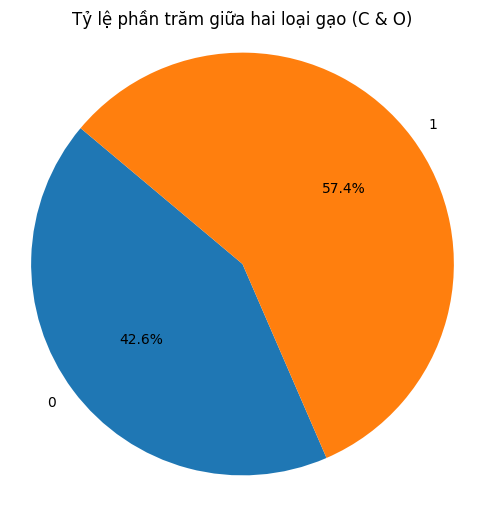

In [9]:
# ====== Biểu đồ tròn ======
counts = Counter(y_encoded)
labels = list(counts.keys())
sizes = list(counts.values())
colors = ["#1f77b4", "#ff7f0e"]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title("Tỷ lệ phần trăm giữa hai loại gạo (C & O)")
plt.axis('equal')
plt.show()

## **4. PHÂN TÍCH TRỰC QUAN**

### **Boxplot từng thuộc tính trước - sau khi xử lý**

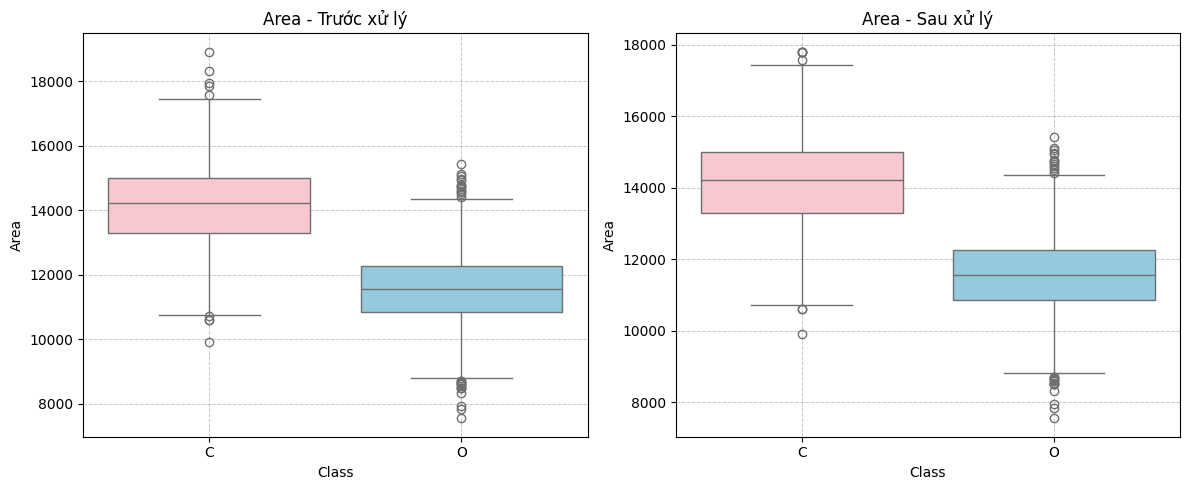

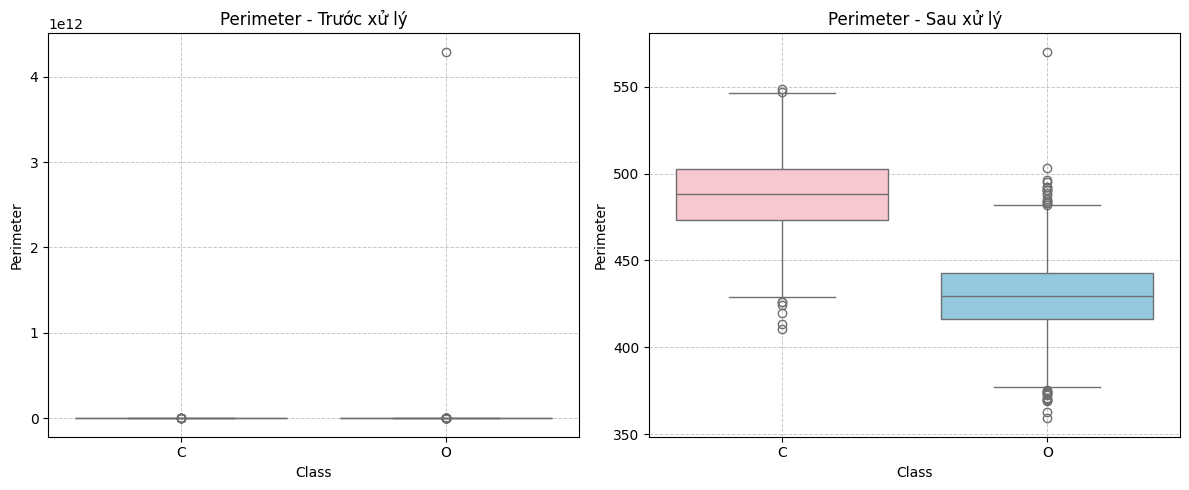

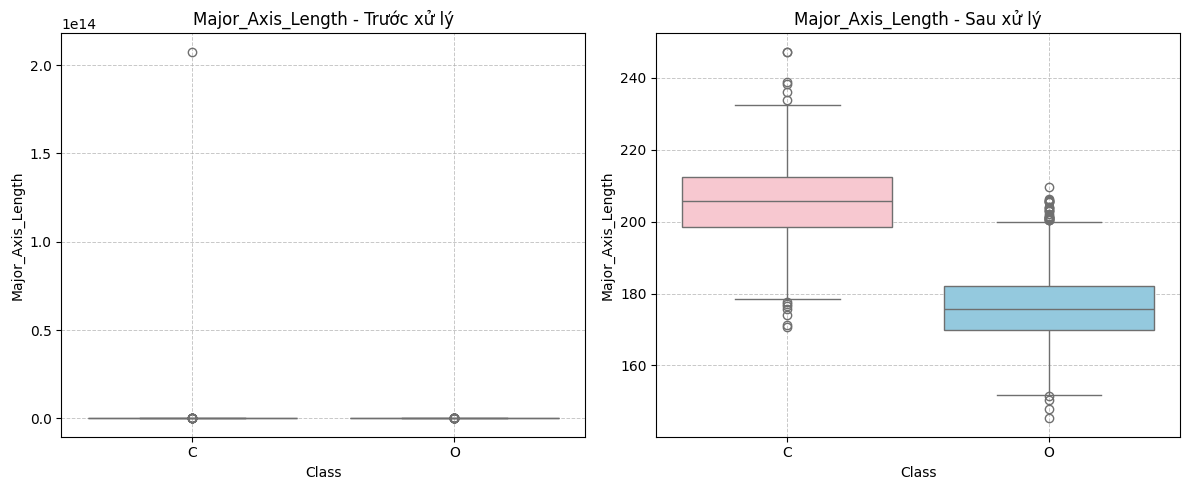

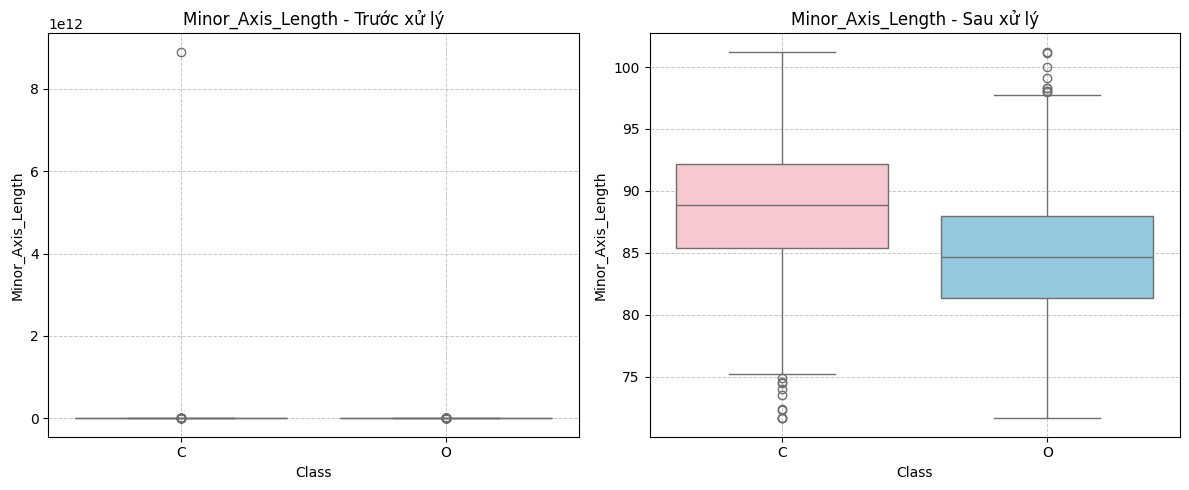

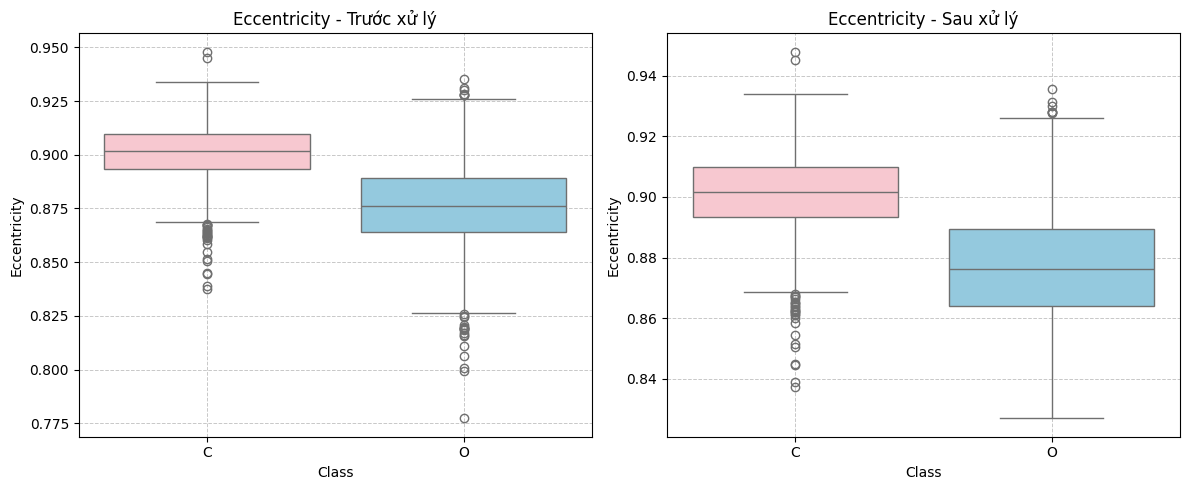

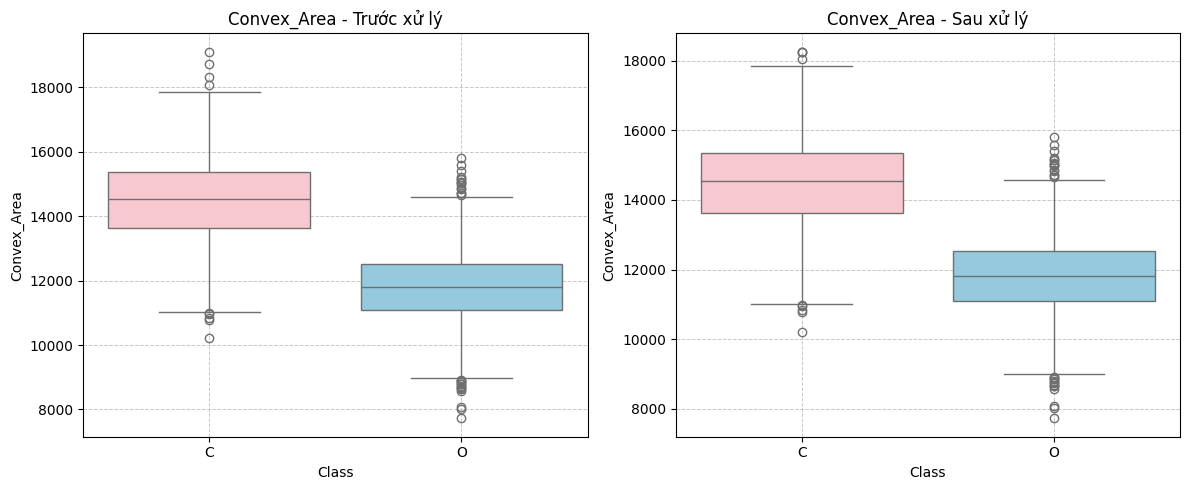

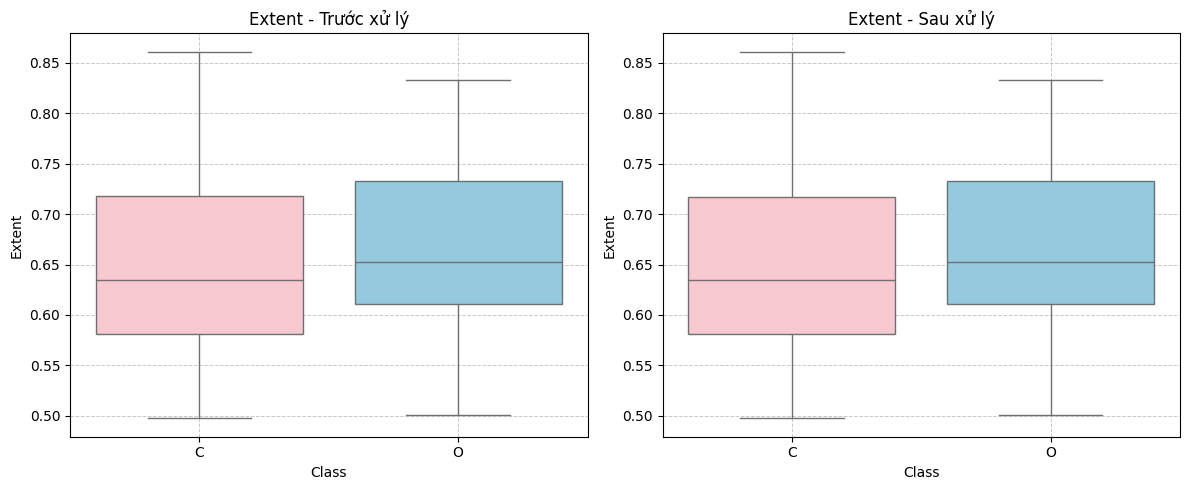

In [ ]:
# Chọn các cột feature có trong cả data_original và data
features_to_plot = [col for col in FEATURE_COLUMNS if col in data_original.columns and col in data.columns]

for col in features_to_plot:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Trước xử lý
    sns.boxplot(
        x='Class',
        y=col,
        hue='Class',
        data=data_original,
        palette=['pink', 'skyblue'],
        ax=axes[0],
        dodge=False,
        legend=False
    )
    axes[0].set_title(f'{col} - Trước xử lý')
    axes[0].grid(True, linestyle='--', linewidth=0.7, alpha=0.7)  # Thêm grid ngang

    # Sau xử lý
    sns.boxplot(
        x='Class',
        y=col,
        hue='Class',
        data=data,
        palette=['pink', 'skyblue'],
        ax=axes[1],
        dodge=False,
        legend=False
    )
    axes[1].set_title(f'{col} - Sau xử lý')
    axes[1].grid(True, linestyle='--', linewidth=0.7, alpha=0.7)  # Thêm grid ngang

    plt.tight_layout()
    plt.show()


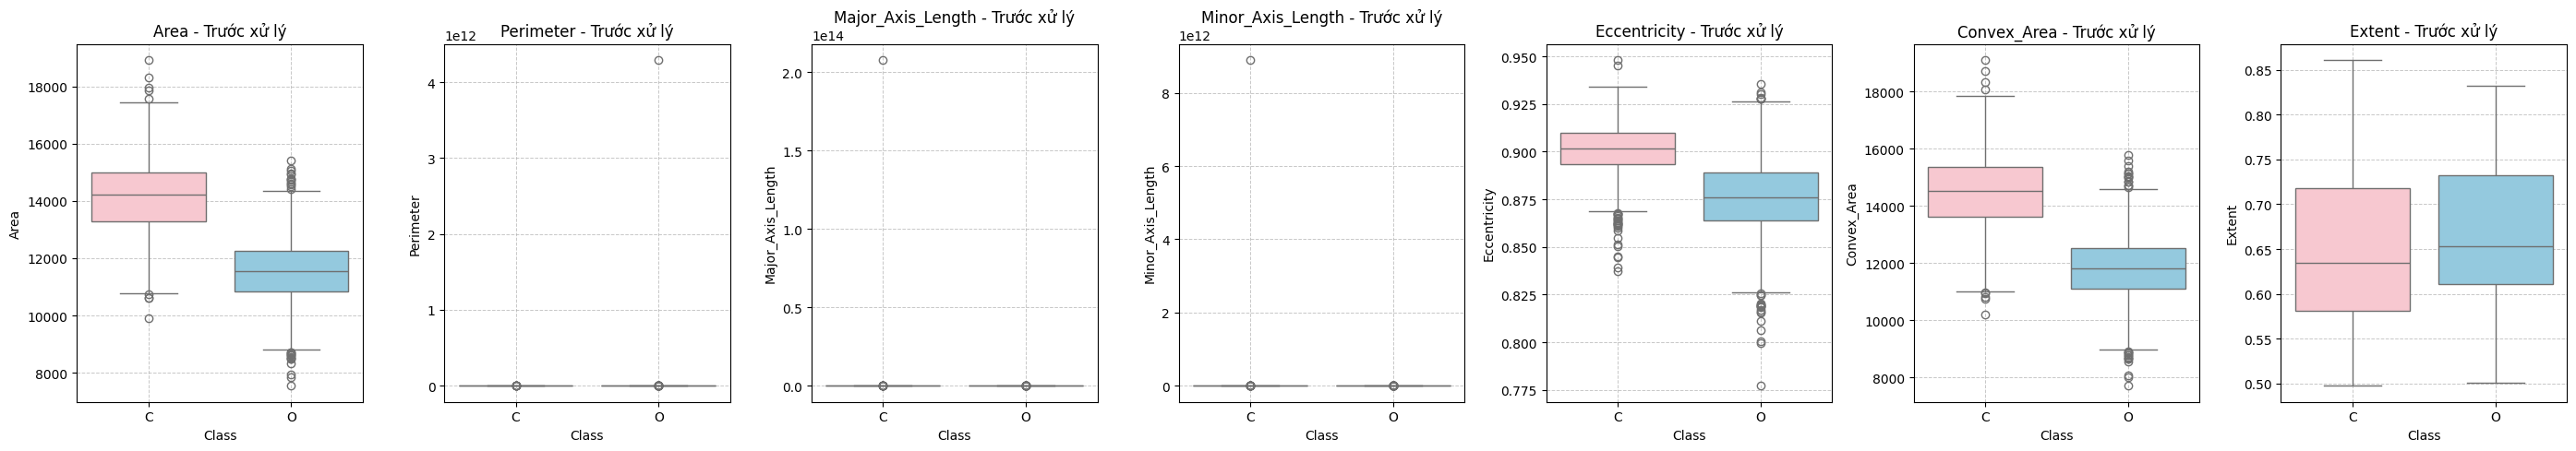

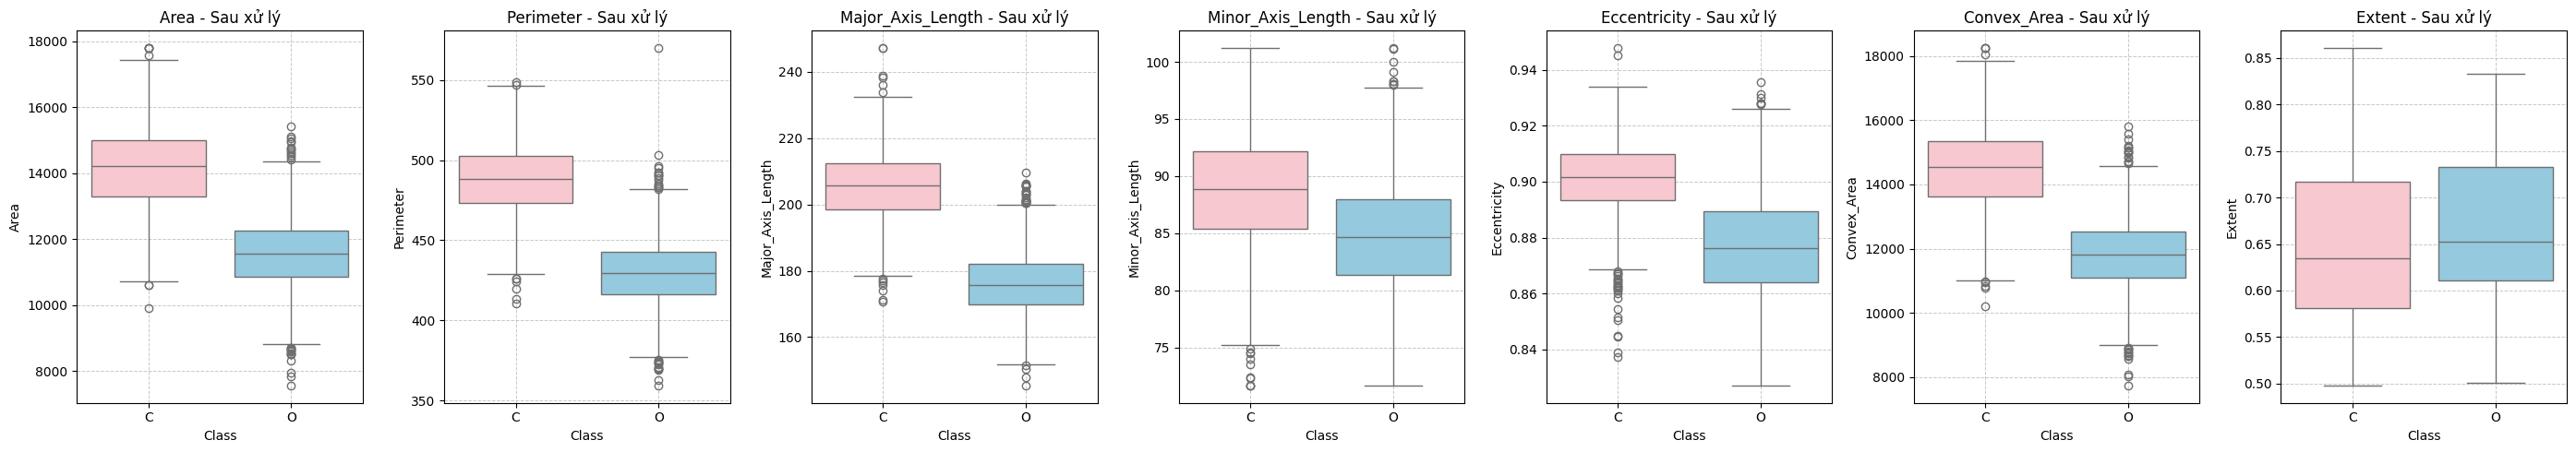

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chọn các feature hợp lệ có trong cả data_original và data
features_to_plot = [col for col in FEATURE_COLUMNS if col in data_original.columns and col in data.columns]

# --- Trước xử lý (dùng data gốc) ---
fig, axes = plt.subplots(1, len(features_to_plot), figsize=(4*len(features_to_plot), 5), sharey=False)

for i, col in enumerate(features_to_plot):
    sns.boxplot(
        x='Class',
        y=col,
        hue='Class',
        data=data_original,  # Dữ liệu gốc trước xử lý
        palette={'C': 'pink', 'O': 'skyblue'},
        ax=axes[i],
        dodge=False,
        legend=False
    )
    axes[i].set_title(f'{col} - Trước xử lý')
    axes[i].grid(True, linestyle='--', linewidth=0.7, alpha=0.7)

plt.tight_layout()
plt.show()


# --- Sau xử lý (dùng data đã xử lý) ---
fig, axes = plt.subplots(1, len(features_to_plot), figsize=(4*len(features_to_plot), 5), sharey=False)

for i, col in enumerate(features_to_plot):
    sns.boxplot(
        x='Class',
        y=col,
        hue='Class',
        data=data,  # Dữ liệu sau xử lý
        palette={'C': 'pink', 'O': 'skyblue'},
        ax=axes[i],
        dodge=False,
        legend=False
    )
    axes[i].set_title(f'{col} - Sau xử lý')
    axes[i].grid(True, linestyle='--', linewidth=0.7, alpha=0.7)

plt.tight_layout()
plt.show()


### **Ma trận tương quan**

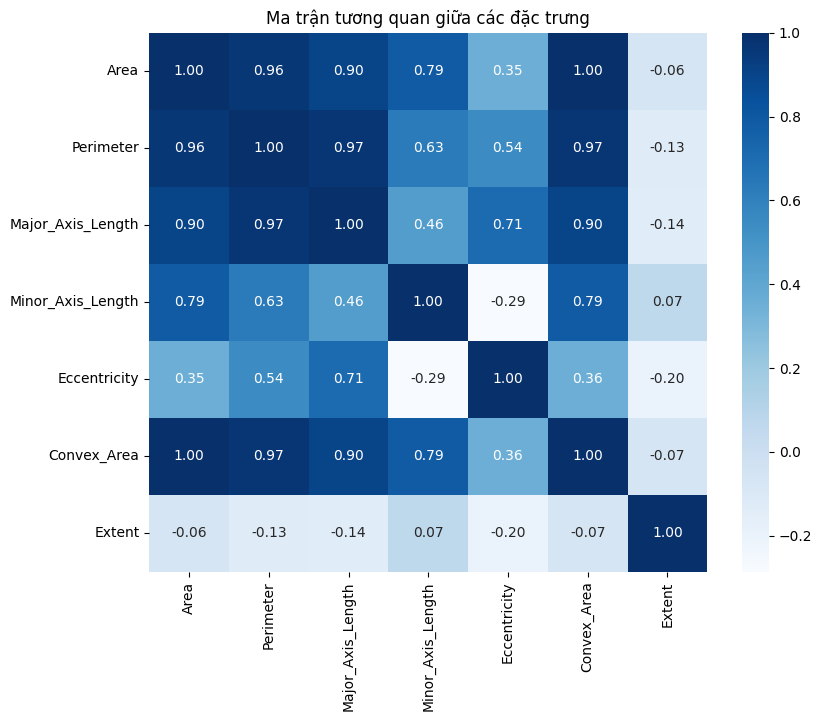

In [ ]:
# Ma trận tương quan
plt.figure(figsize=(9, 7))
sns.heatmap(pd.DataFrame(X, columns=FEATURE_COLUMNS).corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Ma trận tương quan giữa các đặc trưng")
plt.show()

### **PCA trực quan hóa**

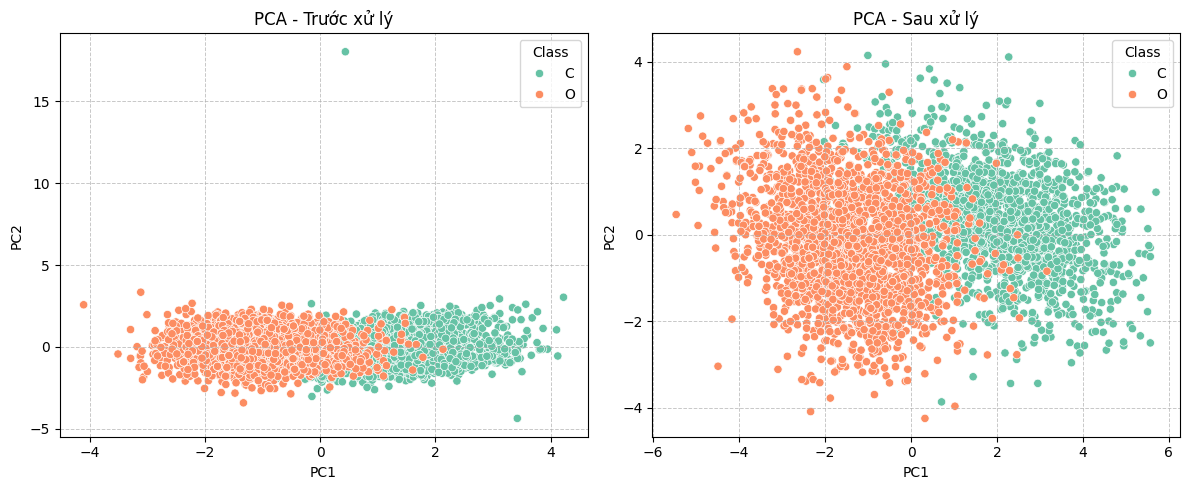

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# --- PCA TRƯỚC XỬ LÝ ---
# Sử dụng data_original đã được làm sạch và điền giá trị thiếu
existing_numeric_features_orig = [col for col in FEATURE_COLUMNS if col in data_original.columns]
X_original = data_original[existing_numeric_features_orig].copy()

# Điền giá trị thiếu trong X_original
imputer_orig = SimpleImputer(strategy='mean')
X_original_imputed = imputer_orig.fit_transform(X_original)

if X_original_imputed is not None and X_original_imputed.shape[1] >= 2:
    scaler_orig = StandardScaler()
    X_orig_scaled = scaler_orig.fit_transform(X_original_imputed)  # Chuẩn hóa dữ liệu
    pca_orig = PCA(n_components=2)  # PCA giảm chiều xuống 2 thành phần chính
    X_orig_pca = pca_orig.fit_transform(X_orig_scaled)
else:
    X_orig_pca = None
    print("Không đủ đặc trưng số trong data_original để thực hiện PCA trước xử lý.")

# --- PCA SAU XỬ LÝ ---
# Sử dụng data đã được làm sạch và điền giá trị thiếu
existing_numeric_features = [col for col in FEATURE_COLUMNS if col in data.columns]
X_proc = data[existing_numeric_features].copy()

if not X_proc.empty and X_proc.shape[1] >= 2:
    scaler_proc = StandardScaler()
    X_proc_scaled = scaler_proc.fit_transform(X_proc)  # Chuẩn hóa dữ liệu
    pca_proc = PCA(n_components=2)  # PCA giảm chiều xuống 2 thành phần chính
    X_proc_pca = pca_proc.fit_transform(X_proc_scaled)
else:
    X_proc_pca = None
    print("Không đủ đặc trưng số trong data để thực hiện PCA sau xử lý.")

# --- Vẽ lưới PCA 2 cột: trước & sau ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Trước xử lý
if X_orig_pca is not None and 'data_original' in locals() and 'Class' in data_original.columns:
    sns.scatterplot(
        x=X_orig_pca[:, 0],
        y=X_orig_pca[:, 1],
        hue=data_original['Class'],
        palette='Set2',
        ax=axes[0]
    )
    axes[0].set_title("PCA - Trước xử lý")
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    axes[0].grid(True, linestyle='--', linewidth=0.7, alpha=0.7)

else:
    axes[0].set_title("PCA - Trước xử lý (Data not available)")
    axes[0].text(0.5, 0.5, "Không thể vẽ PCA trước xử lý",
                 horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes)

# Sau xử lý
if X_proc_pca is not None and 'data' in locals() and 'Class' in data.columns:
    sns.scatterplot(
        x=X_proc_pca[:, 0],
        y=X_proc_pca[:, 1],
        hue=data['Class'],
        palette='Set2',
        ax=axes[1]
    )
    axes[1].set_title("PCA - Sau xử lý")
    axes[1].set_xlabel("PC1")
    axes[1].set_ylabel("PC2")
    axes[1].grid(True, linestyle='--', linewidth=0.7, alpha=0.7)

else:
    axes[1].set_title("PCA - Sau xử lý (Data not available)")
    axes[1].text(0.5, 0.5, "Không thể vẽ PCA sau xử lý",
                 horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()


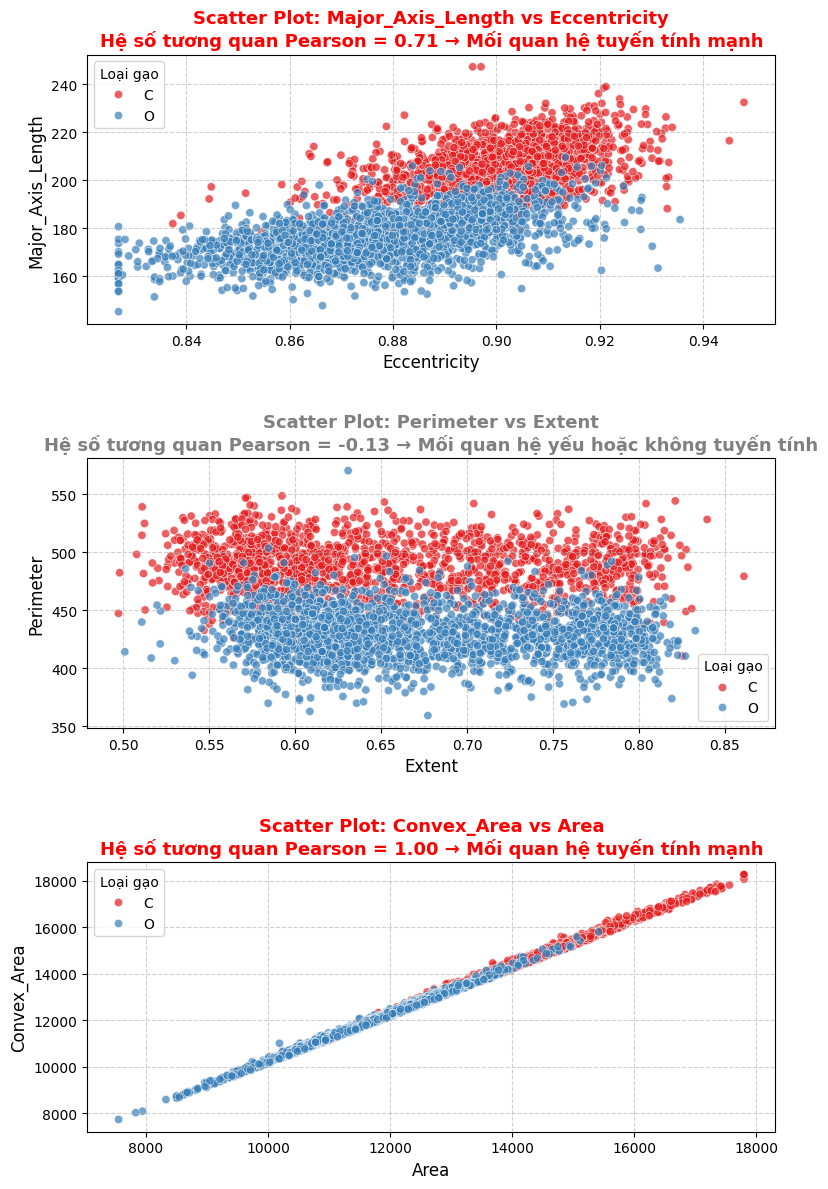

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Danh sách các cặp thuộc tính cần vẽ Scatter Plot
scatter_pairs = [
    ('Eccentricity', 'Major_Axis_Length'),
    ('Extent', 'Perimeter'),
    ('Area', 'Convex_Area')
]

plt.figure(figsize=(8, 4 * len(scatter_pairs)))

# Lặp qua từng cặp thuộc tính để vẽ và kiểm tra tương quan
for i, (x_col, y_col) in enumerate(scatter_pairs):
    if x_col in data.columns and y_col in data.columns:
        # Tính hệ số tương quan Pearson (chỉ tính trên các giá trị hợp lệ)
        corr_value = data[[x_col, y_col]].corr(method='pearson').iloc[0, 1]

        # Xác định màu chữ tuỳ theo mức độ tương quan
        corr_strength = abs(corr_value)
        if corr_strength > 0.7:
            relation = "→ Mối quan hệ tuyến tính mạnh"
            color = "red"
        elif corr_strength > 0.4:
            relation = "→ Mối quan hệ tuyến tính vừa"
            color = "orange"
        else:
            relation = "→ Mối quan hệ yếu hoặc không tuyến tính"
            color = "gray"

        # Vẽ scatter plot
        plt.subplot(len(scatter_pairs), 1, i + 1)
        sns.scatterplot(
            x=x_col,
            y=y_col,
            hue='Class',
            data=data,
            palette='Set1',
            alpha=0.7
        )

        plt.title(
            f'Scatter Plot: {y_col} vs {x_col}\n'
            f'Hệ số tương quan Pearson = {corr_value:.2f} {relation}',
            fontsize=13,
            color=color,
            fontweight='bold'
        )
        plt.xlabel(x_col, fontsize=12)
        plt.ylabel(y_col, fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(title='Loại gạo')
    else:
        print(f"Cảnh báo: Cột '{x_col}' hoặc '{y_col}' không tồn tại trong dữ liệu.")

plt.tight_layout(h_pad=3.0)
plt.show()



Đang vẽ Pair Plot cho tất cả các đặc trưng số...


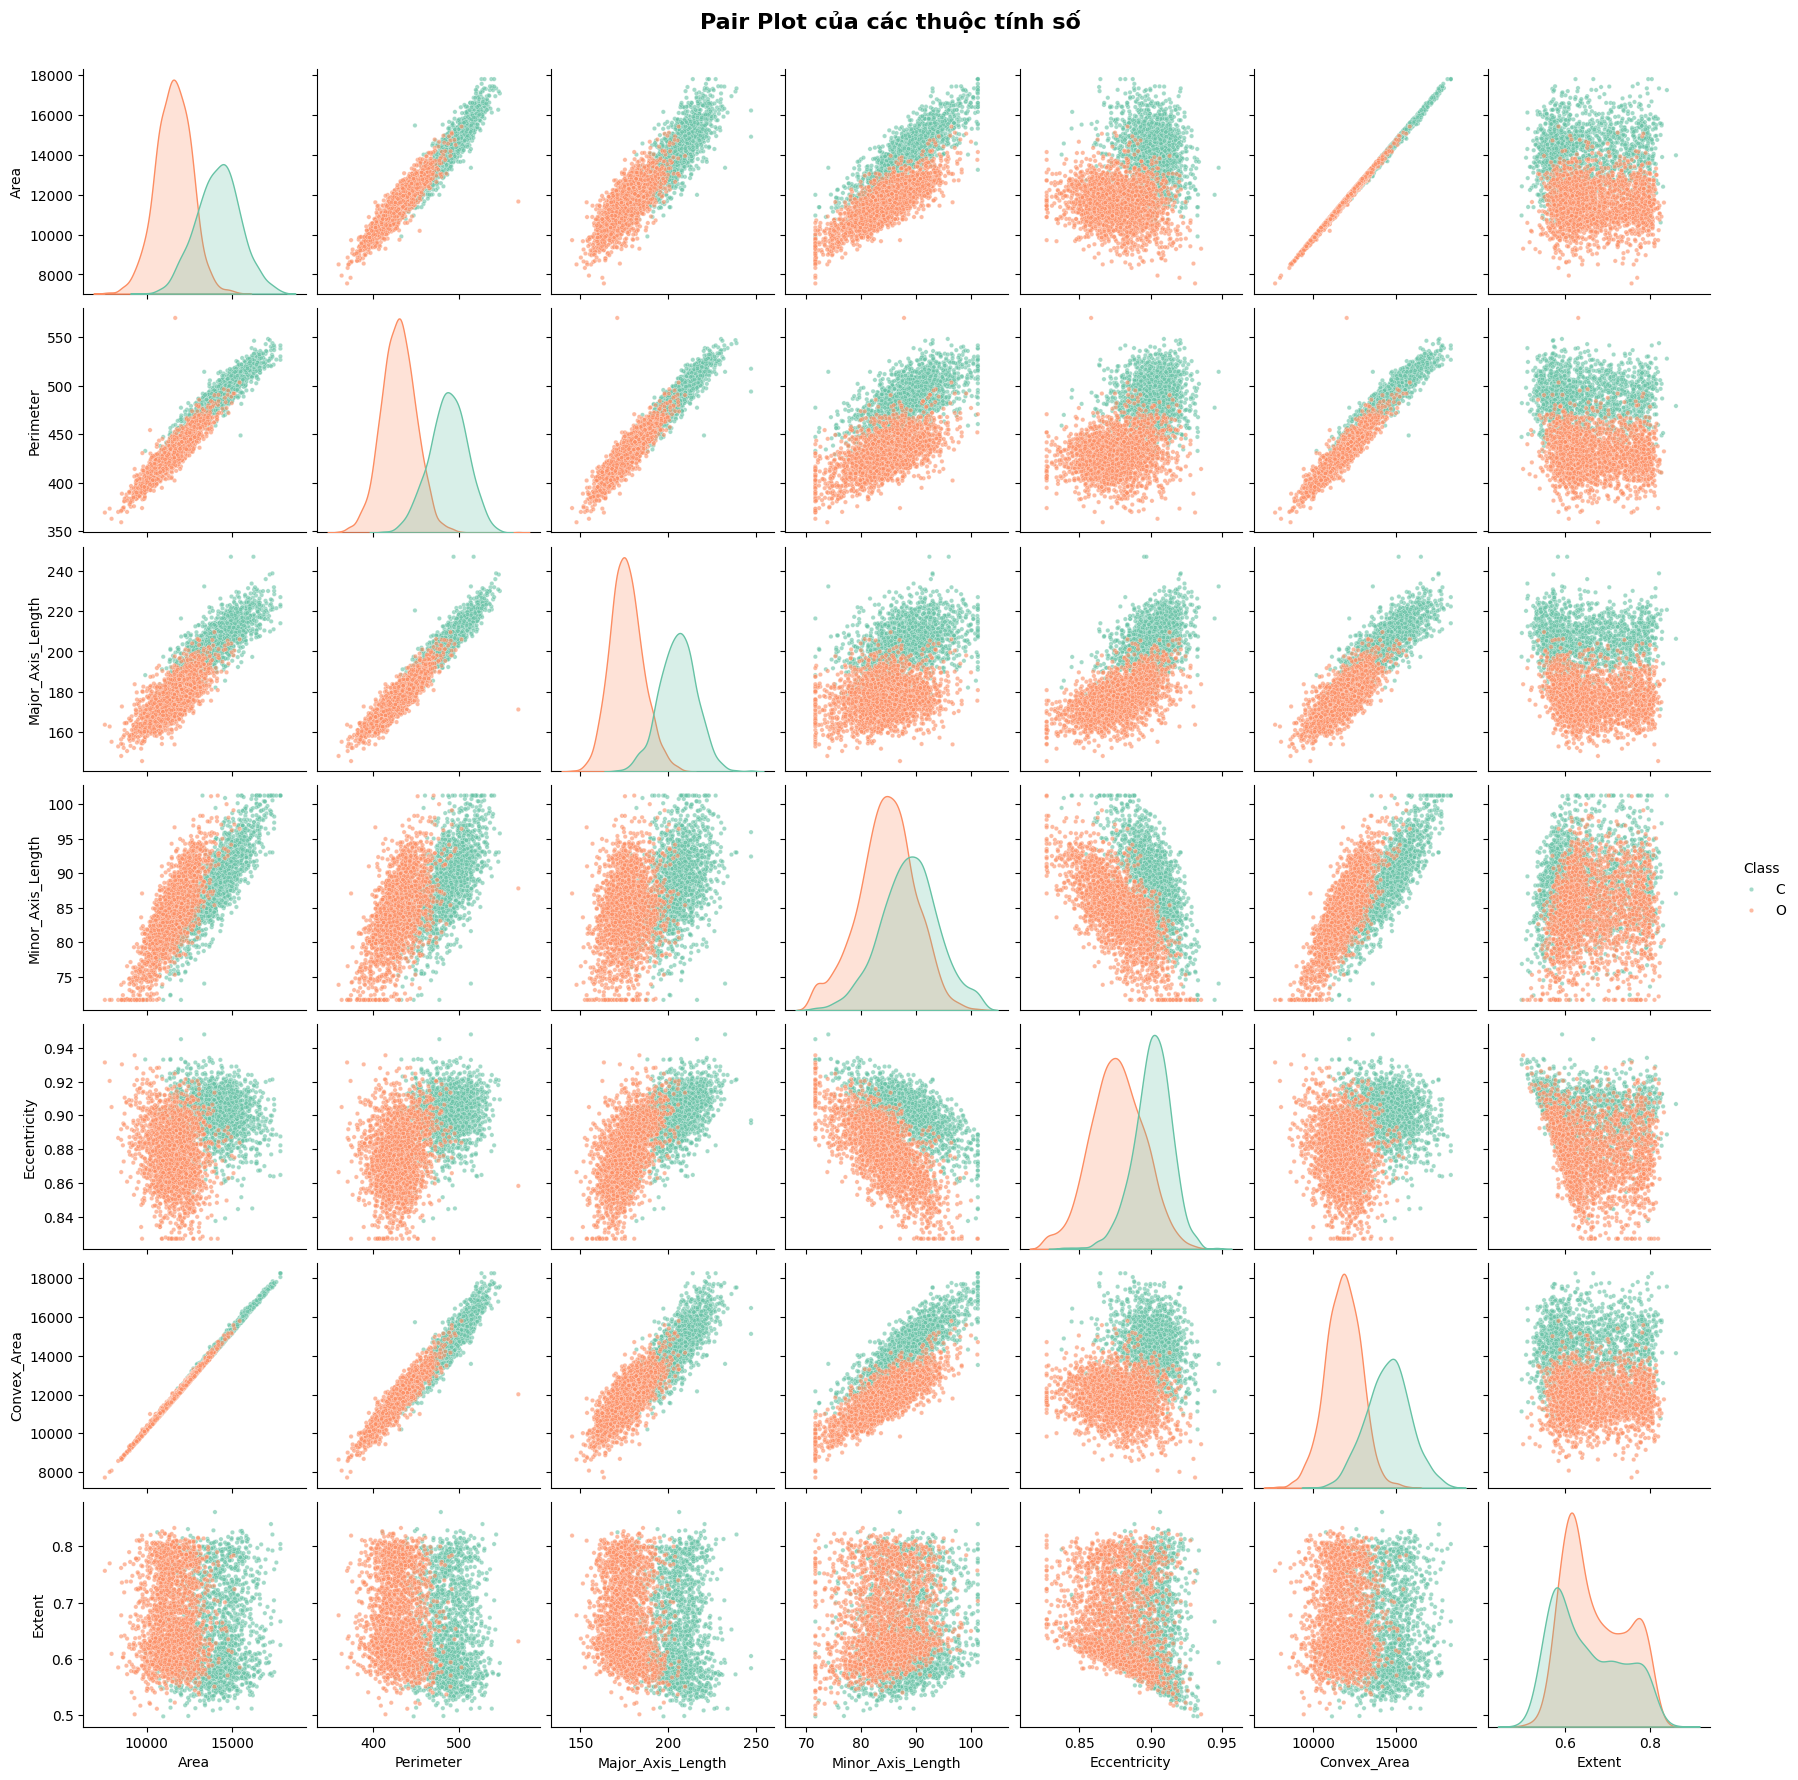

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print("\nĐang vẽ Pair Plot cho tất cả các đặc trưng số...")

# Đảm bảo chỉ chọn các cột số đã được xử lý
# existing_numeric_features là danh sách đã được định nghĩa trong code của bạn.
plot_data = data[existing_numeric_features + ['Class']]

# Vẽ Pair Plot
# hue='Class' để tô màu các điểm theo loại gạo (C/O)
# corner=True để chỉ vẽ nửa dưới ma trận, giúp gọn gàng hơn
# palette='viridis' là một lựa chọn màu sắc khác
sns.pairplot(
    data=plot_data,
    hue='Class',
    palette='Set2',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 10},
    # diag_kind='hist' cũng là một lựa chọn phổ biến
)

plt.suptitle("Pair Plot của các thuộc tính số", y=1.02, fontsize=16, fontweight='bold')
plt.show()

### **Histogram + KDE**


Vẽ Histogram + KDE cho các đặc trưng (sau impute)


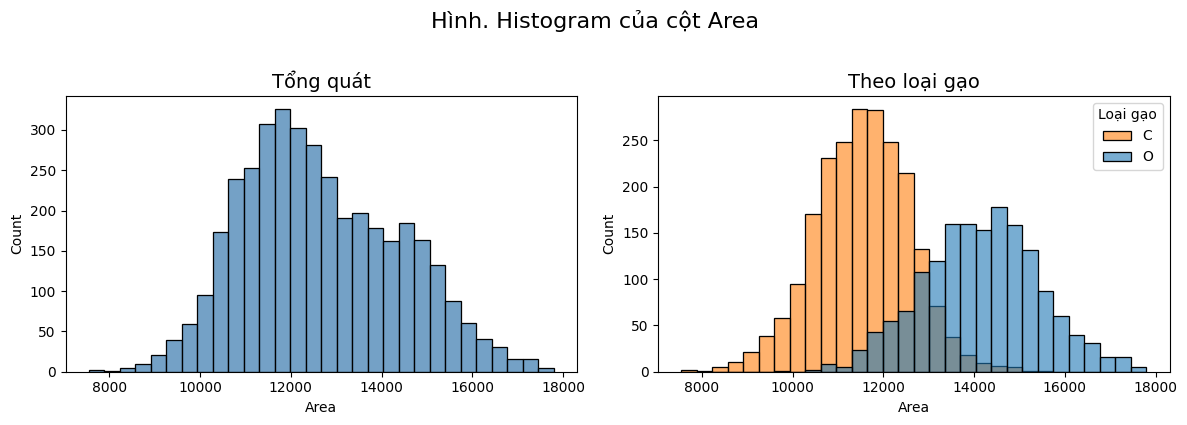

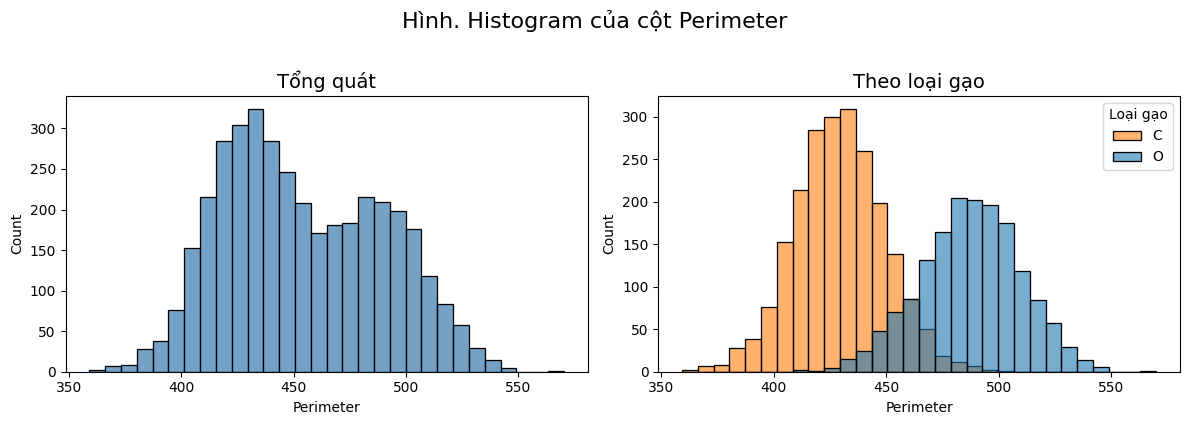

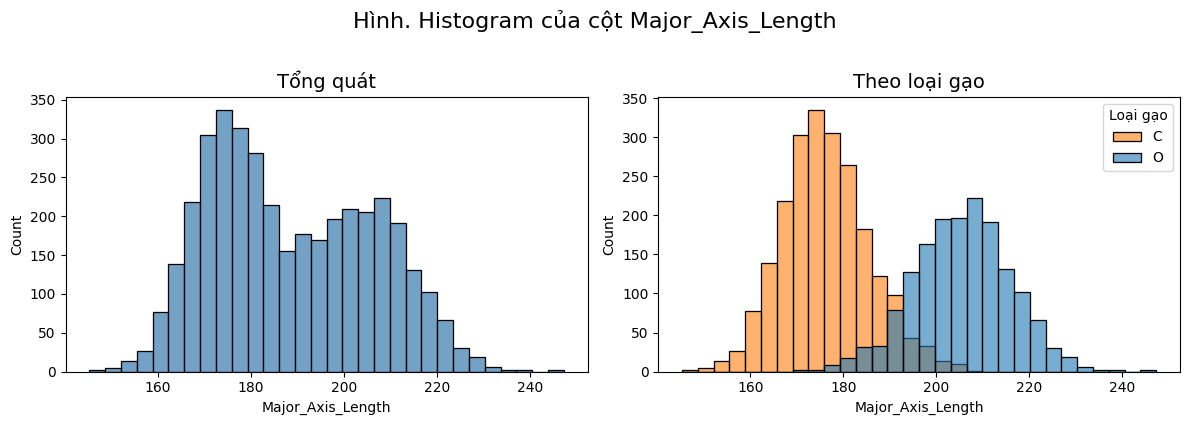

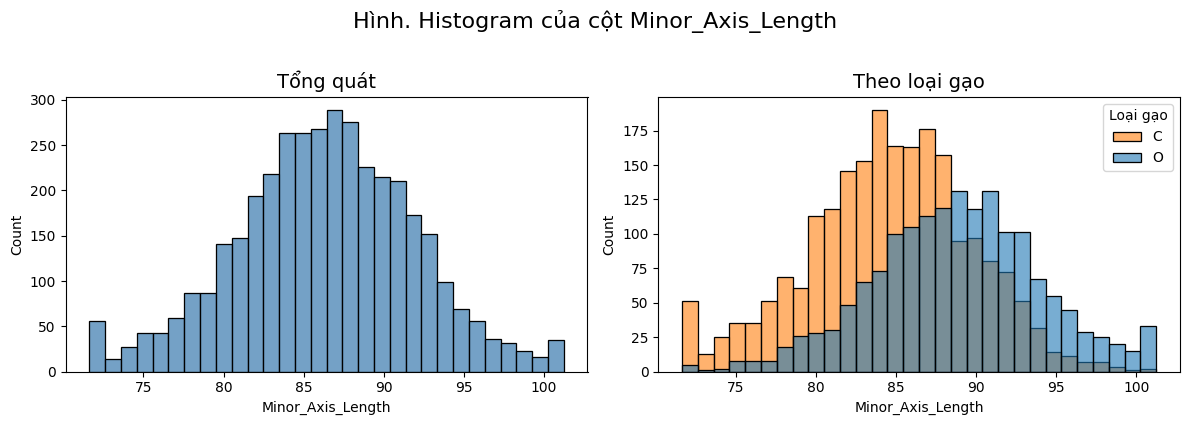

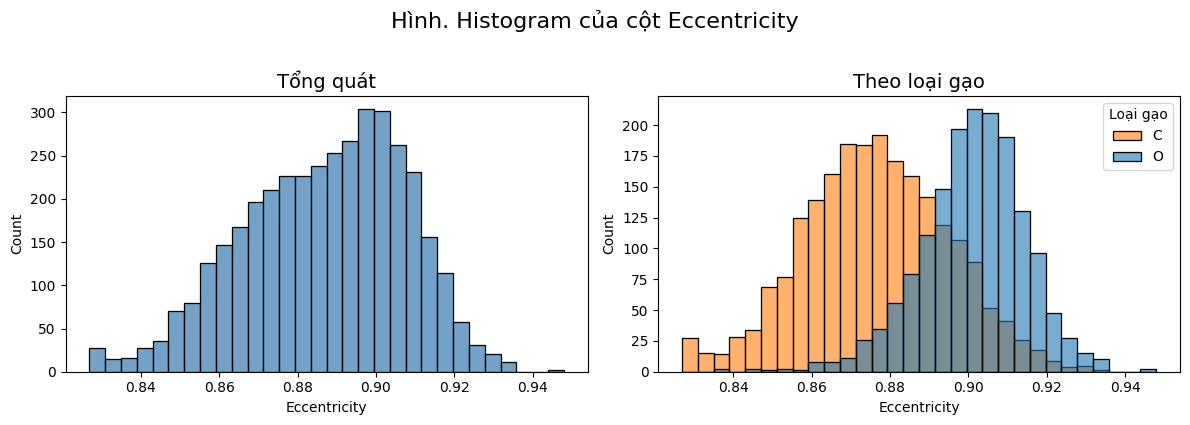

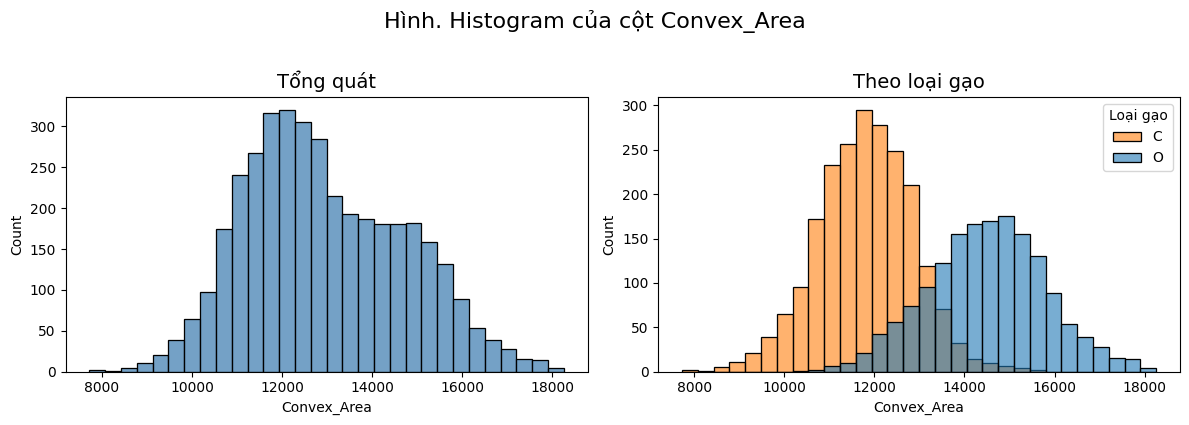

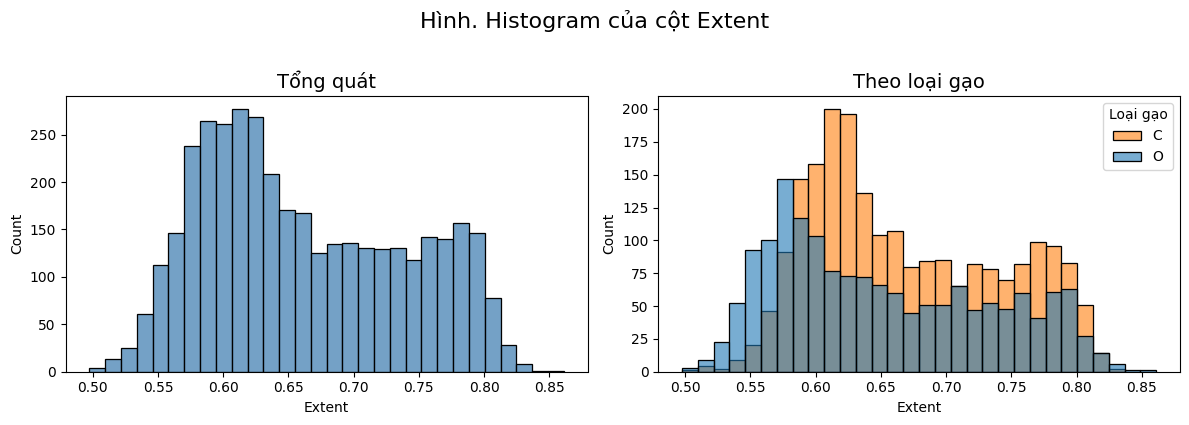


Hoàn thành việc vẽ biểu đồ cho toàn bộ các đặc trưng số.


In [ ]:
print("\nVẽ Histogram + KDE cho các đặc trưng (sau impute)")
LOAI_GAO_COLUMN = 'Class'
for col in existing_numeric_features:
    # Chỉ vẽ cho các cột có kiểu dữ liệu là số (numeric)
    if pd.api.types.is_numeric_dtype(data[col]):

        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

        # --- Panel 1 (Trái): Phân phối Chung (Tổng quát) ---
        sns.histplot(
            data=data,
            x=col,
            kde=False,
            bins=30,
            ax=axes[0],
            color="steelblue"
        )
        axes[0].set_title("Tổng quát", fontsize=14)
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Count")

        # --- Panel 2 (Phải): Phân phối theo Loại Gạo (Theo loại gạo) ---
        sns.histplot(
            data=data,
            x=col,
            hue=LOAI_GAO_COLUMN,
            kde=False,
            bins=30,
            ax=axes[1],
            alpha=0.6
        )
        axes[1].set_title("Theo loại gạo", fontsize=14)
        axes[1].set_xlabel(col)
        axes[1].set_ylabel("Count")

        try:
            unique_labels = data[LOAI_GAO_COLUMN].unique()
            axes[1].legend(title='Loại gạo', labels=unique_labels, loc='upper right')
        except:
             pass

        # Đặt tiêu đề chung cho cả 2 biểu đồ
        fig.suptitle(f"Hình. Histogram của cột {col}", fontsize=16, y=1.05)

        plt.tight_layout(rect=[0, 0, 1, 1.03])
        plt.show()
print("\nHoàn thành việc vẽ biểu đồ cho toàn bộ các đặc trưng số.")

## **5. XÂY DỰNG & ĐÁNH GIÁ MÔ HÌNH**

### **Chạy nhiều tham số**

Đã loại bỏ cột 'Convex_Area' trước khi huấn luyện.

--- Đang tìm tham số tối ưu cho mô hình: kNN ---
Fitting 3 folds for each of 224 candidates, totalling 672 fits
Best params cho kNN: {'metric': 'minkowski', 'n_neighbors': 28, 'weights': 'distance'}
Accuracy: 0.9306 | F1: 0.9306 | Recall: 0.9306 | Precision: 0.9306
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       353
           1       0.94      0.93      0.94       411

    accuracy                           0.93       764
   macro avg       0.93      0.93      0.93       764
weighted avg       0.93      0.93      0.93       764



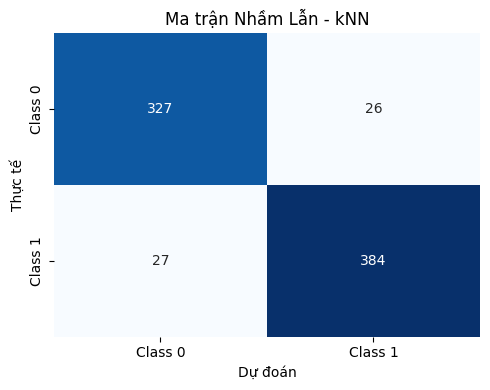


--- Đang tìm tham số tối ưu cho mô hình: Decision Tree ---
Fitting 3 folds for each of 1944 candidates, totalling 5832 fits
Best params cho Decision Tree: {'class_weight': 'balanced', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Accuracy: 0.9254 | F1: 0.9253 | Recall: 0.9254 | Precision: 0.9254
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       353
           1       0.92      0.94      0.93       411

    accuracy                           0.93       764
   macro avg       0.93      0.92      0.92       764
weighted avg       0.93      0.93      0.93       764



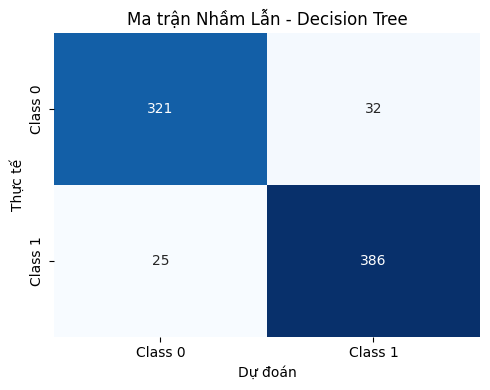


--- Đang tìm tham số tối ưu cho mô hình: Logistic Regression ---
Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best params cho Logistic Regression: {'C': 5, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 0.9254 | F1: 0.9254 | Recall: 0.9254 | Precision: 0.9256
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       353
           1       0.94      0.92      0.93       411

    accuracy                           0.93       764
   macro avg       0.92      0.93      0.93       764
weighted avg       0.93      0.93      0.93       764



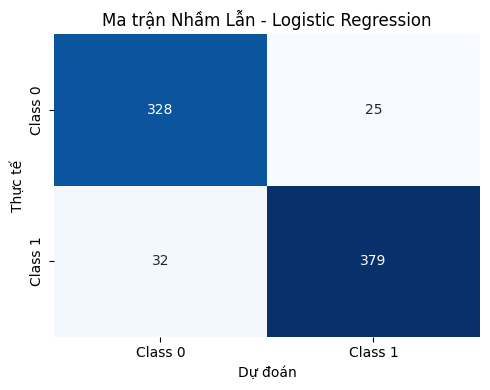


--- Đang tìm tham số tối ưu cho mô hình: SVM ---
Fitting 3 folds for each of 600 candidates, totalling 1800 fits
Best params cho SVM: {'C': 50, 'class_weight': 'balanced', 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy: 0.9241 | F1: 0.9241 | Recall: 0.9241 | Precision: 0.9244
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       353
           1       0.94      0.92      0.93       411

    accuracy                           0.92       764
   macro avg       0.92      0.92      0.92       764
weighted avg       0.92      0.92      0.92       764



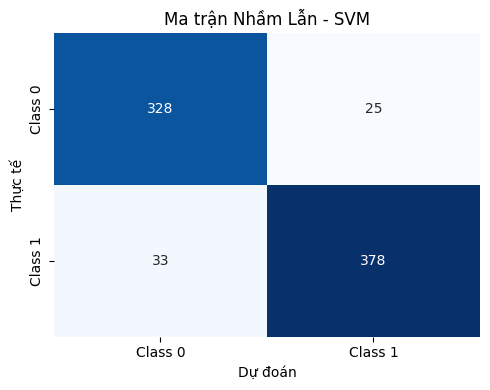


--- Đang tìm tham số tối ưu cho mô hình: MLP ---
Fitting 3 folds for each of 192 candidates, totalling 576 fits
Best params cho MLP: {'activation': 'logistic', 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant', 'max_iter': 500, 'solver': 'adam'}
Accuracy: 0.9293 | F1: 0.9293 | Recall: 0.9293 | Precision: 0.9294
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       353
           1       0.94      0.93      0.93       411

    accuracy                           0.93       764
   macro avg       0.93      0.93      0.93       764
weighted avg       0.93      0.93      0.93       764



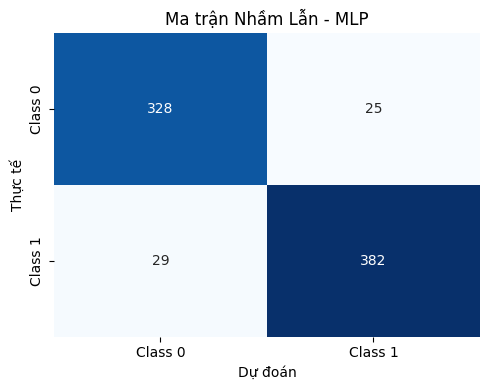


=== Kết quả Tổng hợp ===


,Model,Best_Params,Accuracy,F1-Score,Recall,Precision
0,kNN,"{'metric': 'minkowski', 'n_neighbors': 28, 'we...",0.930628,0.930635,0.930628,0.930645
4,MLP,"{'activation': 'logistic', 'hidden_layer_sizes...",0.929319,0.929346,0.929319,0.929423
2,Logistic Regression,"{'C': 5, 'class_weight': 'balanced', 'max_iter...",0.925393,0.925439,0.925393,0.925640
1,Decision Tree,"{'class_weight': 'balanced', 'max_depth': 3, '...",0.925393,0.925334,0.925393,0.925432
3,SVM,"{'C': 50, 'class_weight': 'balanced', 'degree'...",0.924084,0.924136,0.924084,0.924391


In [ ]:
# ================================
# 4. HUẤN LUYỆN & ĐÁNH GIÁ MÔ HÌNH (Data đã cắt Convex_Area)
# ================================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ===============================
# DỮ LIỆU: loại bỏ 'Convex_Area'
# ===============================
X_cut = pd.DataFrame(X, columns=FEATURE_COLUMNS).copy()
if 'Convex_Area' in X_cut.columns:
    X_cut.drop('Convex_Area', axis=1, inplace=True)
    print("Đã loại bỏ cột 'Convex_Area' trước khi huấn luyện.")

y_cut = y_encoded

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_cut, y_cut, test_size=0.2, random_state=42
)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# Định nghĩa mô hình & lưới tham số rộng hơn
# ===============================
models = {
    "kNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "SVM": SVC(random_state=42),
    "MLP": MLPClassifier(random_state=42, max_iter=1500)
}

param_grids = {
    "kNN": {
        'n_neighbors': list(range(3, 31)),
        'weights': ['uniform', 'distance'],
        'metric': ['minkowski', 'euclidean', 'manhattan', 'chebyshev']
    },
    "Decision Tree": {
        'max_depth': list(range(3, 21)),
        'min_samples_split': [2, 4, 6, 8, 10, 12],
        'min_samples_leaf': [1, 2, 4],
        'max_features': [None, 'sqrt', 'log2'],
        'class_weight': ['balanced', None]
    },
    "Logistic Regression": {
        'C': [0.01, 0.1, 0.5, 1, 5, 10],
        'solver': ['lbfgs', 'liblinear', 'saga'],
        'penalty': ['l2'],
        'class_weight': ['balanced', None],
        'max_iter': [1000, 2000]
    },
    "SVM": {
        'C': [0.01, 0.1, 1, 10, 50],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1],
        'kernel': ['rbf', 'linear', 'poly', 'sigmoid'],
        'degree': [2, 3, 4],
        'class_weight': ['balanced', None]
    },
    "MLP": {
        'hidden_layer_sizes': [(50,), (100,), (100, 50), (150, 100, 50)],
        'activation': ['relu', 'tanh', 'logistic'],
        'solver': ['adam', 'sgd'],
        'learning_rate': ['constant', 'adaptive'],
        'max_iter': [500, 800, 1000, 1500]
    }
}

# ===============================
# SMOTE cho dữ liệu huấn luyện
# ===============================
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# ===============================
# Huấn luyện từng mô hình
# ===============================
results = []

for name, model in models.items():
    print(f"\n--- Đang tìm tham số tối ưu cho mô hình: {name} ---")

    param_grid = param_grids.get(name, {})
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='f1_weighted',
        cv=3,
        n_jobs=-1,
        verbose=1
    )


    grid_search.fit(X_train_resampled, y_train_resampled)
    best_model = grid_search.best_estimator_

    print(f"Best params cho {name}: {grid_search.best_params_}")

    y_pred = best_model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')

    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f} | Recall: {recall:.4f} | Precision: {precision:.4f}")
    print(classification_report(y_test, y_pred))

    results.append({
        'Model': name,
        'Best_Params': grid_search.best_params_,
        'Accuracy': acc,
        'F1-Score': f1,
        'Recall': recall,
        'Precision': precision
    })

    # --- Ma trận nhầm lẫn ---
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
    plt.title(f"Ma trận Nhầm Lẫn - {name}")
    plt.xlabel("Dự đoán")
    plt.ylabel("Thực tế")
    plt.tight_layout()
    plt.show()

# ===============================
# Kết quả tổng hợp
# ===============================
results_df = pd.DataFrame(results)
print("\n=== Kết quả Tổng hợp ===")
display(results_df.sort_values(by='F1-Score', ascending=False))


In [ ]:

results_df_short = pd.DataFrame(results)

# Rút gọn Best_Params nếu quá dài
results_df_short['Best_Params'] = results_df_short['Best_Params'].apply(lambda x: str(x)[:50] + '...' if len(str(x)) > 50 else str(x))

# Sắp xếp theo F1-Score giảm dần
results_df_short = results_df_short.sort_values(by='F1-Score', ascending=False)

# In ra bảng cuối gọn
print("\n=== Bảng Kết quả Tổng hợp Các Mô hình ===")
print(results_df_short[['Model', 'Accuracy', 'F1-Score', 'Recall', 'Precision']].to_string(index=False))



=== Bảng Kết quả Tổng hợp Các Mô hình ===
              Model  Accuracy  F1-Score   Recall  Precision
                kNN  0.930628  0.930635 0.930628   0.930645
                MLP  0.929319  0.929346 0.929319   0.929423
Logistic Regression  0.925393  0.925439 0.925393   0.925640
      Decision Tree  0.925393  0.925334 0.925393   0.925432
                SVM  0.924084  0.924136 0.924084   0.924391


### **Vẽ biểu đồ so sánh các giải thuật**

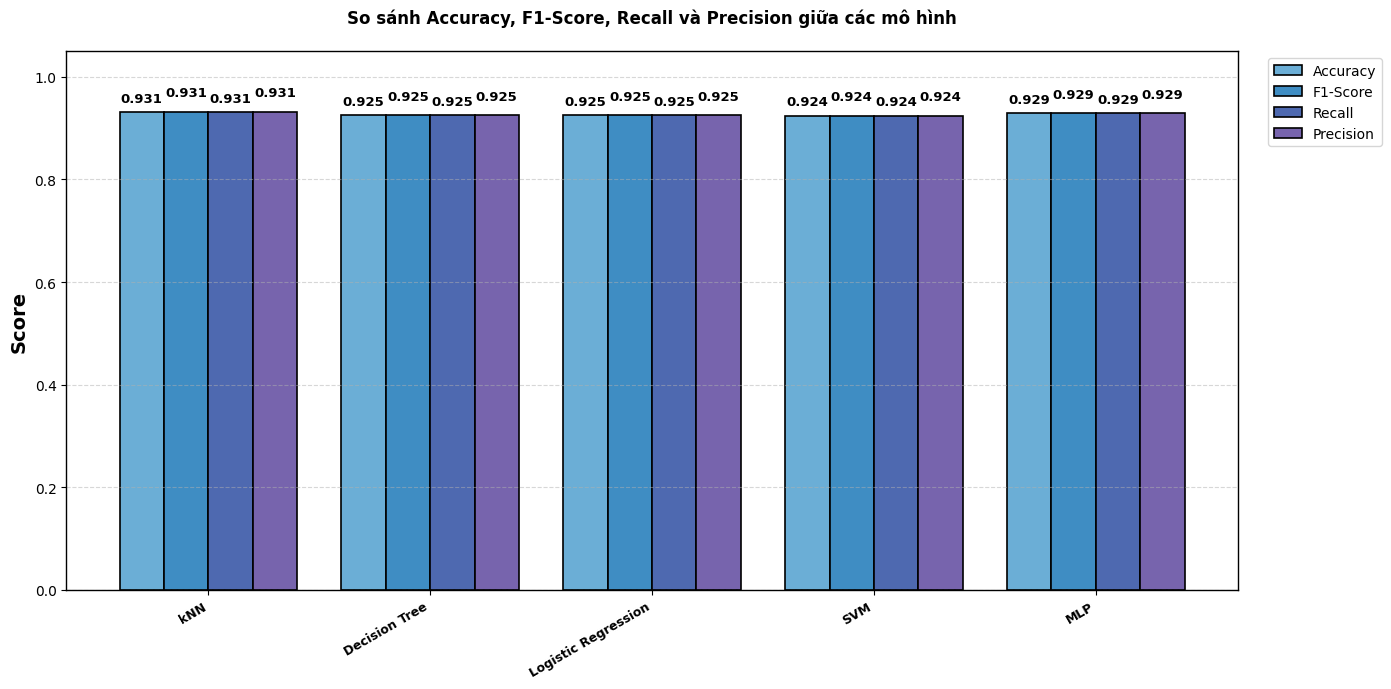

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

# Dữ liệu mẫu (Giữ nguyên)
data = {
    'Model': ['kNN', 'Decision Tree', 'Logistic Regression', 'SVM', 'MLP'],
    'Accuracy': [0.931, 0.925, 0.925, 0.924, 0.929],
    'F1-Score': [0.931, 0.925, 0.925, 0.924, 0.929],
    'Recall': [0.931, 0.925, 0.925, 0.924, 0.929],
    'Precision': [0.931, 0.925, 0.925, 0.924, 0.929]
}
results_df = pd.DataFrame(data)

metrics = ['Accuracy', 'F1-Score', 'Recall', 'Precision']
num_models = len(results_df)
num_metrics = len(metrics)

bar_width = 0.20
group_gap = 0.2
x = np.arange(num_models) * (bar_width*num_metrics + group_gap)

# 1. Định nghĩa Figure và Axes (Buộc nền Figure và Axes là trắng)
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

plt.rcParams['hatch.linewidth'] = 0.5

# === Gradient colors ===
cmap = LinearSegmentedColormap.from_list("custom_gradient", ["#6baed6", "#3182bd", "#6a51a3", "#9e9ac8"])
colors = [cmap(i/num_metrics) for i in range(num_metrics)]

# Vẽ cột
for i, metric in enumerate(metrics):
    ax.bar(x + i*bar_width, results_df[metric], width=bar_width,
            label=metric, color=colors[i], edgecolor='black', linewidth=1.2)

# Xticks (Buộc màu đen)
ax.set_xticks(x + (num_metrics-1)*bar_width/2)
ax.set_xticklabels(results_df['Model'], rotation=30, ha='right', fontsize=9, weight='bold', color='black')

ax.set_ylim(0, 1.05)
ax.set_ylabel("Score", fontsize=14, weight='bold', color='black')
ax.set_title("So sánh Accuracy, F1-Score, Recall và Precision giữa các mô hình",
          fontsize=12, weight='bold', pad=20, color='black')

# Buộc các đường viền trục (spines) và tick labels phải màu đen
ax.tick_params(axis='x', colors='black') # Màu chữ tick X
ax.tick_params(axis='y', colors='black') # Màu chữ tick Y

for spine in ax.spines.values():
    spine.set_edgecolor('black') # Màu đường viền trục
    spine.set_linewidth(1) # Độ dày đường viền

ax.grid(axis='y', linestyle='--', alpha=0.5)

# === ĐIỀU CHỈNH CHÚ THÍCH SANG PHẢI ===
ax.legend(fontsize=10, loc='upper left', bbox_to_anchor=(1.02, 1))

# === Đảm bảo Chữ MÀU ĐEN và KHÔNG CHỒNG LẤN (Offset Y tách biệt) ===
y_offsets = [0.015, 0.025, 0.015, 0.025]

for i in range(num_models):
    for j, metric in enumerate(metrics):
        value = results_df[metric][i]

        y_pos = value + y_offsets[j]
        x_pos = x[i] + j * bar_width

        ax.text(x_pos, y_pos, f"{value:.3f}", ha='center', va='bottom', fontsize=9.5, weight='bold', color='black')

plt.tight_layout()
plt.show()

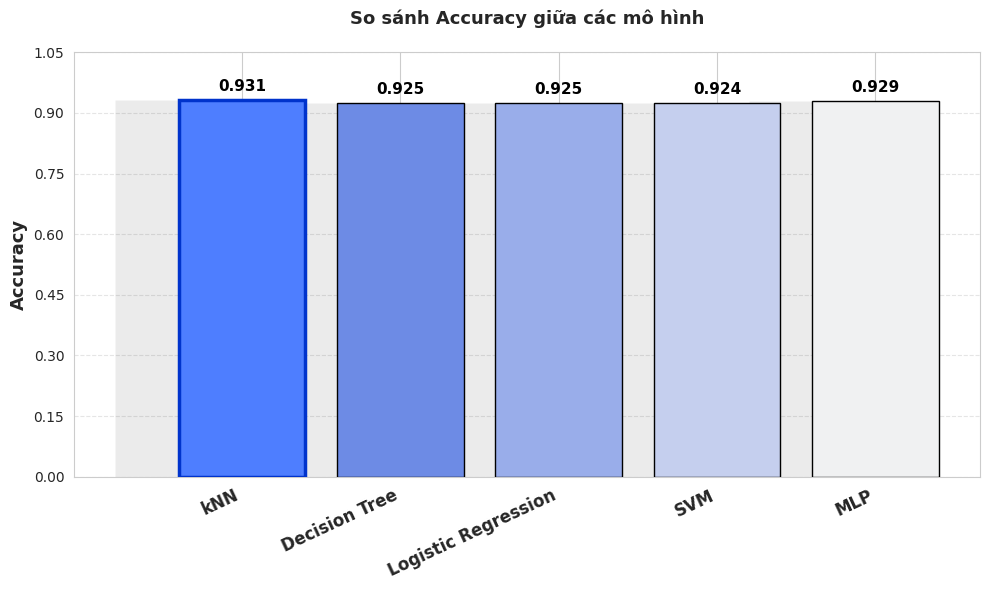

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

metric = 'Accuracy'
x = np.arange(len(results_df))

#  Tạo bảng màu gradient đậm dần (tông xanh lam sang trọng)
base_palette = sns.light_palette("royalblue", n_colors=len(results_df), reverse=True)
colors = base_palette.copy()

# Xác định mô hình có Accuracy cao nhất
best_idx = results_df[metric].idxmax()
best_pos = list(results_df.index).index(best_idx)

#  Tăng độ đậm cho cột cao nhất (cùng tông)
colors[best_pos] = tuple(min(c * 1.2, 1.0) for c in colors[best_pos])

plt.figure(figsize=(10, 6), facecolor='white')
sns.set_style("whitegrid")

#  Vẽ cột chính
bars = plt.bar(
    x,
    results_df[metric],
    color=colors,
    edgecolor='black',
    linewidth=1,
    zorder=3,
)

# Thêm hiệu ứng bóng nhẹ phía sau (cho cảm giác nổi)
for bar in bars:
    plt.bar(
        bar.get_x(),
        bar.get_height(),
        width=bar.get_width(),
        color='black',
        alpha=0.08,
        zorder=2
    )

#  Cài đặt trục và nhãn
plt.xticks(x, results_df['Model'], rotation=25, ha='right', fontsize=12, weight='bold')
plt.ylim(0, 1.00)
plt.yticks(np.arange(0, 1.05 + 0.001, 0.15))  # ticks từ 0, 0.15, 0.30, ...
plt.ylabel("Accuracy", fontsize=13, weight='bold')
plt.title("So sánh Accuracy giữa các mô hình", fontsize=13, weight='bold', pad=20)

# Lưới nhẹ nhàng
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
plt.gca().set_axisbelow(True)

#  Hiển thị giá trị trên mỗi cột
for bar, color in zip(bars, colors):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.015,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='black',
        zorder=5
    )

# Làm viền nổi bật cho cột có Accuracy cao nhất
bars[best_pos].set_linewidth(2.5)
bars[best_pos].set_edgecolor('#0033cc')  # viền xanh đậm

plt.tight_layout()
plt.show()
